特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名称: ['setosa' 'versicolor' 'virginica']
数据形状: (150, 4)
是否有缺失值: False
测试集准确率: 97.78%

分类报告:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



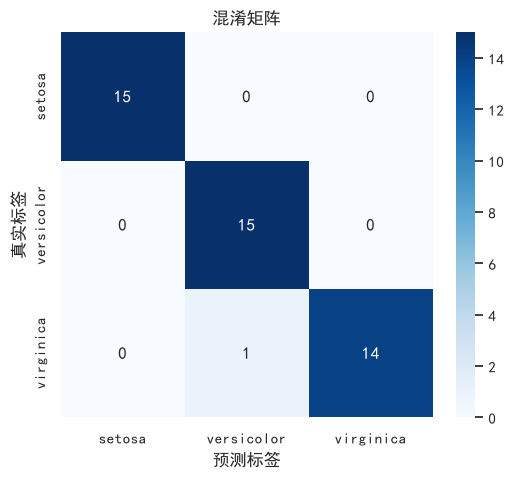


LDA 系数 (coef_):
 [[  5.07607338   4.74964533 -28.0269806  -17.28835989]
 [ -1.19926353  -1.76861284   7.54898745   1.91901225]
 [ -3.87680984  -2.98103249  20.47799315  15.36934765]]
LDA 截距 (intercept_):
 [-29.3503556   -2.76460787 -18.6422177 ]

系数绝对值贡献:
                 sepal length (cm)  sepal width (cm)  petal length (cm)  \
Class0 vs rest           5.076073          4.749645          28.026981   
Class1 vs rest           1.199264          1.768613           7.548987   
Class2 vs rest           3.876810          2.981032          20.477993   

                petal width (cm)  
Class0 vs rest         17.288360  
Class1 vs rest          1.919012  
Class2 vs rest         15.369348  


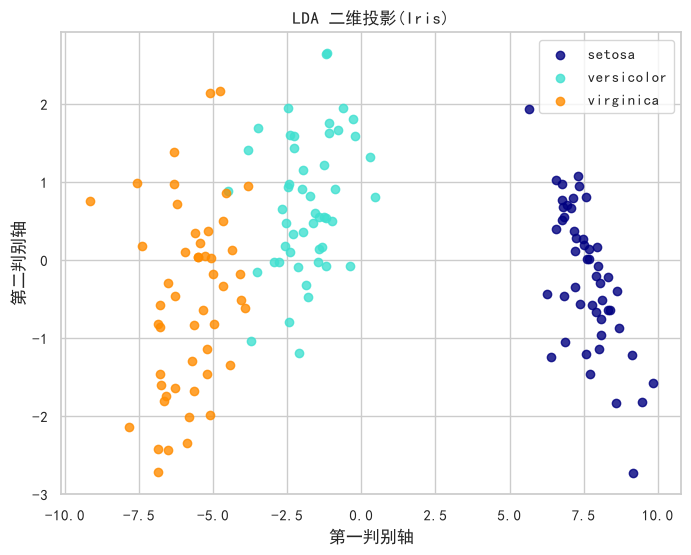

各判别轴解释的方差比例: [0.9912126 0.0087874]
均值m0: [-1.03020449  0.81419604 -1.29484676 -1.24795487]
均值m1: [ 0.08760619 -0.71163664  0.2547855   0.13291827]

类内散度矩阵 S_W:
 [[16.32764617 15.47374431  4.04044043  3.11685938]
 [15.47374431 43.86645405  3.23304883  4.24458841]
 [ 4.04044043  3.23304883  2.6025358   1.72408828]
 [ 3.11685938  4.24458841  1.72408828  2.62418889]]

手写LDA投影向量(归一化): [-0.01558185  0.19047766 -0.73467165 -0.65094779]
sklearn LDA投影向量(归一化): [-0.06993207 -0.14288238  0.79632186  0.58358   ]

方向一致性(绝对值点积应接近1):0.991041


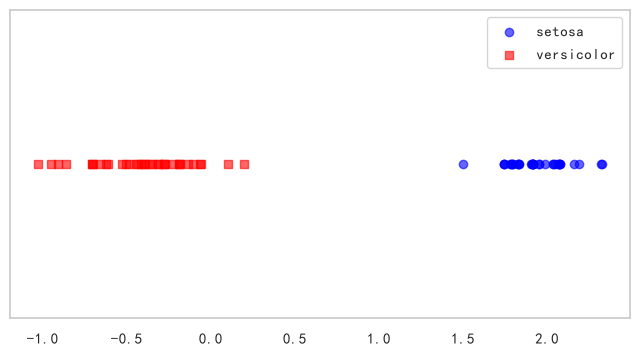

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.decomposition import PCA
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')#全局静默警告
sns.set(style='whitegrid')#设置图表背景纯白，添加浅灰色网格线
%matplotlib inline 
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 优先 SimHei，回退 DejaVu
plt.rcParams['axes.unicode_minus'] = False                    # 解决负号显示问题
#数据加载与预处理
iris = load_iris()#加载sklearn内置iris数据集
X, y = iris.data,iris.target
feature_names = iris.feature_names#获取特征列表
target_names = iris.target_names#获取类别列表
print("特征名称:", feature_names)
print("类别名称:", target_names)
print("数据形状:", X.shape)
print("是否有缺失值:", np.any(pd.DataFrame(X).isnull()))#检查是否有缺失值
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)#stratify=y分层抽样
scaler = StandardScaler()#创建标准化转换器实例
X_train_scaled = scaler.fit_transform(X_train)#标准化训练集数据
X_test_scaled = scaler.transform(X_test)#标准化测试集数据
#任务1 构建鸢尾花分类器，评估性能
lda_clf = LDA()#初始化LDA分类器实例
lda_clf.fit(X_train_scaled,y_train)#模型训练核心步骤
y_pred = lda_clf.predict(X_test_scaled)#输出预测结果
y_prob = lda_clf.predict_proba(X_test_scaled)#输出测试集属于每个类别的概率矩阵
print("测试集准确率: {:.2f}%".format(accuracy_score(y_test, y_pred)*100))
print("\n分类报告:\n", classification_report(y_test, y_pred, target_names=target_names))#一次性生成每个类别的Precision,Recall,F1-Score以及全局汇总指标
cm = confusion_matrix(y_test,y_pred)#计算混淆矩阵
plt.figure(figsize=(6,5))#设置画布大小6×5
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=target_names,yticklabels=target_names)
plt.title('混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()
print("\nLDA 系数 (coef_):\n", lda_clf.coef_)
print("LDA 截距 (intercept_):\n", lda_clf.intercept_)
coef_df = pd.DataFrame(lda_clf.coef_,columns=feature_names,index=[f'Class{i} vs rest' for i in range(3)])
print("\n系数绝对值贡献:\n",coef_df.abs())
#任务2 LDA降维与可视化
lda_vis = LDA(n_components=2)
X_lda = lda_vis.fit_transform(X_train_scaled,y_train)
lda_all = LDA(n_components=2)
X_all_lda = lda_all.fit_transform(scaler.fit_transform(X),y)
plt.figure(figsize=(8,6))
colors =['navy','turquoise','darkorange']
for color,i,target_name in zip(colors,[0,1,2],target_names):
    plt.scatter(X_all_lda[y == i,0],X_all_lda[y == i,1],alpha=0.8,color=color,label=target_name)
plt.title('LDA 二维投影(Iris)')
plt.xlabel('第一判别轴')
plt.ylabel('第二判别轴')
plt.legend()
plt.grid(True)
plt.show()
print("各判别轴解释的方差比例:", lda_all.explained_variance_ratio_)
#任务三 手写二分类LDA与sklearn对比
mask = (y_train ==0) | (y_train == 1)
X_bin = X_train_scaled[mask]
y_bin = y_train[mask]
X0 = X_bin[y_bin == 0]
X1 = X_bin[y_bin == 1]
m0 = np.mean(X0,axis=0)
m1 = np.mean(X1,axis=0)
print('均值m0:',m0)
print('均值m1:',m1)
S_W = np.zeros((4,4))
D0 = X0 - m0
D1 = X1 - m1
S_W = D0.T @ D0 + D1.T @ D1
print('\n类内散度矩阵 S_W:\n',S_W)
lambda_reg = 1
S_W_inv = np.linalg.inv(S_W + lambda_reg * np.eye(S_W.shape[0]))
w_manual = S_W_inv @ (m0 - m1)
w_manual = w_manual / np.linalg.norm(w_manual)
print('\n手写LDA投影向量(归一化):',w_manual)
lda_sk = LDA()
lda_sk.fit(X_bin,y_bin)
w_sklearn = lda_sk.coef_[0]
w_sklearn = w_sklearn / np.linalg.norm(w_sklearn)
print('sklearn LDA投影向量(归一化):',w_sklearn)
dot_product = np.abs(np.dot(w_manual,w_sklearn))
print('\n方向一致性(绝对值点积应接近1):{:.6f}'.format(dot_product))
proj_manual = X_bin @ w_manual
plt.figure(figsize=(8,4))
for label,marker,color in zip([0,1],['o','s'],['blue','red']):
    plt.scatter(proj_manual[y_bin==label],np.zeros_like(proj_manual[y_bin==label]),
                marker=marker,color=color,alpha=0.6,label=target_names[label])
plt.title('')
plt.xlabel('')
plt.legend()
plt.yticks([])
plt.grid(axis='x')
plt.show()
